*GeoPlants Dataset*

## Load Dataset

In [12]:
## Import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Import the created function
from src.utils import merge_metadata_data

- ATENTION

Note that only one path is given for the df containing training data. That is due on the notebook "ecoregions" where the GRECO (Grande Regions Ecologique) was used to interpolate and extracted two more columns at the original dataset. These columns are: GRECO, codeser. Where GRECO is the higher level aggregation and codeser is the so called "sylvioecoregions" which are uniformly representative ecological regions containing agro-forest (silvo pastoril) systems and forest interaction. 

See more at the notebook.

On this case, the path names where changed and now only the train data is called, being stored inside the path: output/ecoregions/train_join.parquet

In [2]:
## Path names
path_train = "/Users/saharmohamed/Documents/ML_Project/Milestone 2/PlantNet-Species-ML-Project/dataset/train_join_agg.parquet"
path_test = ""

In [3]:
## Standard Training dataset load 
df = pd.read_parquet(path_train, engine='fastparquet')

df.head()


,index,surveyId,lon,lat,speciesId,average_Bio1,average_Bio2,average_Bio3,average_Bio4,average_Bio5,...,soilgrids_Soilgrid-cfvo,soilgrids_Soilgrid-clay,soilgrids_Soilgrid-nitrogen,soilgrids_Soilgrid-phh2o,soilgrids_Soilgrid-sand,soilgrids_Soilgrid-silt,soilgrids_Soilgrid-soc,predict,GRECO,codeser
0,0,333,-0.51736,45.80643,2474.0,12.65,8.1,0.3,528.5,25.05,...,176.0,328.0,250.0,71.0,231.0,439.0,257.0,1,F,F11
1,1,410,5.61448,47.21759,2474.0,11.35,8.2,0.3,630.4,24.85,...,128.0,291.0,249.0,56.0,146.0,562.0,338.0,1,C,C11
2,2,779,1.70039,47.64019,2474.0,11.75,7.9,0.3,569.8,24.55,...,98.0,181.0,139.0,56.0,524.0,293.0,238.0,1,B,B10
3,3,1218,2.71272,47.76724,2474.0,11.35,7.6,0.3,574.2,24.05,...,117.0,232.0,152.0,56.0,422.0,344.0,232.0,1,B,B10
4,4,2015,4.37398,44.47449,2474.0,13.65,8.9,0.3,643.4,28.55,...,141.0,240.0,205.0,71.0,316.0,443.0,227.0,1,J,J10


In [4]:
df.columns

Index(['index', 'surveyId', 'lon', 'lat', 'speciesId', 'average_Bio1',
       'average_Bio2', 'average_Bio3', 'average_Bio4', 'average_Bio5',
       'average_Bio6', 'average_Bio7', 'average_Bio8', 'average_Bio9',
       'average_Bio10', 'average_Bio11', 'average_Bio12', 'average_Bio13',
       'average_Bio14', 'average_Bio15', 'average_Bio16', 'average_Bio17',
       'average_Bio18', 'average_Bio19', 'elevation_Elevation',
       'footprint_HumanFootprint-Built1994',
       'footprint_HumanFootprint-Built2009',
       'footprint_HumanFootprint-croplands1992',
       'footprint_HumanFootprint-croplands2005',
       'footprint_HumanFootprint-Lights1994',
       'footprint_HumanFootprint-Lights2009',
       'footprint_HumanFootprint-NavWater1994',
       'footprint_HumanFootprint-NavWater2009',
       'footprint_HumanFootprint-Pasture1993',
       'footprint_HumanFootprint-Pasture2009',
       'footprint_HumanFootprint-Popdensity1990',
       'footprint_HumanFootprint-Popdensity2010',
   

In [6]:
df.shape


(13501, 54)

In [7]:
df.describe()

,index,surveyId,lon,lat,speciesId,average_Bio1,average_Bio2,average_Bio3,average_Bio4,average_Bio5,...,soilgrids_Soilgrid-bdod,soilgrids_Soilgrid-cec,soilgrids_Soilgrid-cfvo,soilgrids_Soilgrid-clay,soilgrids_Soilgrid-nitrogen,soilgrids_Soilgrid-phh2o,soilgrids_Soilgrid-sand,soilgrids_Soilgrid-silt,soilgrids_Soilgrid-soc,predict
count,13501.000000,1.350100e+04,13501.000000,13501.000000,13501.000000,13501.000000,13501.000000,13501.000000,13501.00000,13501.000000,...,12721.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12721.000000,13501.000000
mean,6750.000000,1.974825e+06,3.535815,45.555749,4217.797645,11.718499,7.738486,0.285660,570.65110,24.391175,...,129.167204,216.766842,152.492117,259.120561,264.744784,64.277035,308.138876,431.250597,344.416005,0.457744
std,3897.547327,1.143194e+06,2.502080,2.163481,2952.351493,2.683031,1.389297,0.035677,53.77136,2.741278,...,10.482943,34.778230,37.574728,53.746545,89.327301,6.611551,113.543059,83.107518,142.976811,0.498230
min,0.000000,2.120000e+02,-4.737640,41.462870,2.000000,-4.750000,1.600000,0.100000,280.00000,10.150000,...,90.000000,118.000000,40.000000,99.000000,108.000000,48.000000,49.000000,139.000000,121.000000,0.000000
25%,3375.000000,9.759690e+05,1.914750,43.566913,2474.000000,10.250000,7.300000,0.300000,542.90000,22.750000,...,123.000000,193.000000,125.000000,220.000000,199.000000,59.000000,230.000000,382.000000,243.000000,0.000000
50%,6750.000000,1.992117e+06,3.674850,45.083650,2474.000000,11.550000,7.700000,0.300000,571.70000,24.250000,...,131.000000,213.000000,150.000000,258.000000,249.000000,64.000000,303.000000,425.000000,315.000000,0.000000
75%,10125.000000,2.969912e+06,5.581500,47.563230,6119.000000,13.650000,8.500000,0.300000,600.80000,26.150000,...,136.000000,235.000000,177.000000,292.000000,308.000000,69.000000,378.000000,485.000000,399.000000,1.000000
max,13500.000000,3.918720e+06,9.537180,51.084580,11240.000000,16.950000,11.700000,0.400000,745.40000,31.350000,...,155.000000,384.000000,329.000000,515.000000,678.000000,79.000000,760.000000,720.000000,1066.000000,1.000000


In [5]:
df.shape

(13501, 54)

In [6]:
df.set_index("surveyId",inplace=True)

## Select the X train dataset
## Drop non feature columns but preserve the df to map easily
## since the order to the X index is the same order of the df.

columns_to_drop = ['lon','lat','speciesId','predict','GRECO','codeser','index']

X = df.drop(columns=columns_to_drop)

y = df[['predict']]

In [7]:
X.shape, y.shape

((13501, 46), (13501, 1))

In [8]:
X.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'footprint_HumanFootprint-Built1994',
       'footprint_HumanFootprint-Built2009',
       'footprint_HumanFootprint-croplands1992',
       'footprint_HumanFootprint-croplands2005',
       'footprint_HumanFootprint-Lights1994',
       'footprint_HumanFootprint-Lights2009',
       'footprint_HumanFootprint-NavWater1994',
       'footprint_HumanFootprint-NavWater2009',
       'footprint_HumanFootprint-Pasture1993',
       'footprint_HumanFootprint-Pasture2009',
       'footprint_HumanFootprint-Popdensity1990',
       'footprint_HumanFootprint-Popdensity2010',
       'footprint_HumanFootprint-Railways', 'footprint_Hum

## Double check for test files

In [ ]:

## Path to the environmental data "test" that we merged, all the climate values are all together in one df like
## climate, soilgrids, elevation, human footprint..etc
test_metadata_path = "/Users/saharmohamed/Documents/ML_Project/Milestone 1/Safe/PlantNet-Species-ML-Project/train_out/test_join.parquet"

## path to the original presence absence data PA_test_csv file that's for all species around Europe, BUT
## with filtered to France and most common species ID
test_path = "/Users/saharmohamed/Documents/ML_Project/Milestone 1/Safe/PlantNet-Species-ML-Project/train_out/test_metadata.parquet"


In [12]:
test_metadata_path = pd.read_parquet(test_metadata_path, engine='fastparquet')
test_path = pd.read_parquet(test_path, engine='fastparquet')
test_metadata_path.head()

,surveyId,soilgrids_Soilgrid-bdod,soilgrids_Soilgrid-cec,soilgrids_Soilgrid-cfvo,soilgrids_Soilgrid-clay,soilgrids_Soilgrid-nitrogen,soilgrids_Soilgrid-phh2o,soilgrids_Soilgrid-sand,soilgrids_Soilgrid-silt,soilgrids_Soilgrid-soc,...,footprint_HumanFootprint-NavWater1994,footprint_HumanFootprint-NavWater2009,footprint_HumanFootprint-Pasture1993,footprint_HumanFootprint-Pasture2009,footprint_HumanFootprint-Popdensity1990,footprint_HumanFootprint-Popdensity2010,footprint_HumanFootprint-Railways,footprint_HumanFootprint-Roads,footprint_HumanFootprint-HFP1993,footprint_HumanFootprint-HFP2009
0,642,114.0,229.0,96.0,95.0,389.0,48.0,634.0,270.0,891.0,...,0.0,0.0,0.00,0.0,8,8.0,0.0,2.0,29.0,16.0
1,1792,126.0,204.0,156.0,238.0,259.0,68.0,349.0,411.0,311.0,...,4.0,4.0,0.00,0.0,8,9.0,8.0,4.0,44.0,45.0
2,3256,109.0,246.0,193.0,210.0,547.0,59.0,370.0,419.0,717.0,...,0.0,0.0,0.25,0.0,1,2.0,0.0,1.0,2.0,10.0
3,3855,112.0,252.0,195.0,189.0,489.0,60.0,375.0,435.0,571.0,...,0.0,0.0,0.00,0.0,4,4.0,0.0,0.0,4.0,11.0
4,4889,113.0,146.0,86.0,96.0,220.0,53.0,751.0,153.0,421.0,...,0.0,0.0,0.00,0.0,5,5.0,0.0,0.0,13.0,5.0


In [13]:
test_path.head()

,surveyId,predictions,lon,lat,year,geoUncertaintyInM,areaInM2,region,country,species_list,contain_specie
index,,,,,,,,,,,
2,3256,6755 8743 5055 790 9170 959,1.843658,42.58006,2018,0.0,-inf,ALPINE,France,"[6755, 8743, 5055, 790, 9170, 959]",0
9,9537,2474 164 6788 1746 10664 8858 9771 4238 10385 ...,5.691200,46.33293,2017,1.0,NaN,CONTINENTAL,France,"[2474, 164, 6788, 1746, 10664, 8858, 9771, 423...",1
11,11849,9458 11028 11193 6491 1519 2643 9119 8601 8391,6.151231,43.08357,2018,10.0,50.0,MEDITERRANEAN,France,"[9458, 11028, 11193, 6491, 1519, 2643, 9119, 8...",0
17,15914,2122 2474 7410 6788 7536 1888 1498 944 11005 4...,5.635420,44.98392,2018,1.0,NaN,ALPINE,France,"[2122, 2474, 7410, 6788, 7536, 1888, 1498, 944...",1
19,18511,5980 10305 5605 4628 6469 1195 822 1957 2101 5...,6.153073,43.10858,2018,10.0,-inf,MEDITERRANEAN,France,"[5980, 10305, 5605, 4628, 6469, 1195, 822, 195...",0


In [ ]:
# ## Create the whole df
# test_df = merge_metadata_data(test_metadata_path,test_path)

# test_df.head()
# # ## drop non necessary columns 
# # df = df.drop(columns = ['year', 'geoUncertaintyInM', 'areaInM2','region', 'country'])
# # df.set_index("surveyId",inplace=True)
# # ## Drop non feature columns but preserve the df to map easily
# # ## since the order to the X index is the same order of the df.
# # columns_to_drop = ['lon', 'lat', 'speciesId','predict']

# # ## this is our datasets for the model traing 
# # X = df.drop(columns=columns_to_drop)

## Pre Processing

### Data Cleaning

In [9]:
import re

hf_cols = ['footprint_HumanFootprint-Built1994','footprint_HumanFootprint-Built2009',
       'footprint_HumanFootprint-croplands1992','footprint_HumanFootprint-croplands2005',
       'footprint_HumanFootprint-Lights1994',  'footprint_HumanFootprint-Lights2009',
       'footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009',
       'footprint_HumanFootprint-Pasture1993',  'footprint_HumanFootprint-Pasture2009',
       'footprint_HumanFootprint-Popdensity1990', 'footprint_HumanFootprint-Popdensity2010',
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']

## Stardadization of data cleaning
## Create a safe copy
Xx = X[hf_cols].copy()

## Replace Wrong Variables present in the HumanFootprint - See section HumanFootprint to understand the why these values are wrong
## Get all columns with value lesser than zero
cols_less_zero = Xx.columns[(Xx<0).any(axis=0)]
print(cols_less_zero)
Xx = Xx.where(Xx > 0, 0.0, axis='index') #replace by zero

## Replace all values above a given threshold
## e.g HF Built should not be bigger than 100
col_to_clean = ['footprint_HumanFootprint-Built1994','footprint_HumanFootprint-Built2009',
                'footprint_HumanFootprint-croplands1992','footprint_HumanFootprint-croplands2005',
                'footprint_HumanFootprint-Lights1994','footprint_HumanFootprint-Lights2009',
                'footprint_HumanFootprint-Pasture1993','footprint_HumanFootprint-Pasture2009']
Xx[col_to_clean] = Xx[col_to_clean].where(Xx[col_to_clean] <= 100, Xx[col_to_clean].median(), axis='index') ## replace by the median 

## Replace HPF by the median
col_to_clean =['footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']
Xx[col_to_clean] = Xx[col_to_clean].where(Xx[col_to_clean]<51, Xx[col_to_clean].median(), axis='index')

## Replace a likely wrong value in Pop Density 
## It just transfer the value of pop density to the next/before pop density year - 97% percentile is 10.0, which means that value above are likely wrong
col90 = ['footprint_HumanFootprint-Popdensity1990']
col2010 = ['footprint_HumanFootprint-Popdensity2010']

print(f" The 96% percentile of the Pop2010: {np.percentile(Xx[col2010],98)}")
print(f" The 96% percentile of the Pop1990: {np.percentile(Xx[col90],98)}")
print(f" Max value Pop2010: {Xx[col2010].max().values}")
print(f" Max value Pop1990: {Xx[col90].max().values}")
#Xx[col90] = Xx[col90].where(Xx[col90]< 11, Xx[col2010], axis='index')
## Replace values of Pop2010 with the same of Pop90
Xx[col2010] = Xx[col2010].where(Xx[col2010]< 11, Xx[col90], axis='index')


# ### CONSTRUCT NEW COLUMNS
## Find columns with year in the name of the column
hf_cols_temp =[]
for i in range(0,len(hf_cols)):
    find_number = re.findall(r'\d{4}$', hf_cols[i].split("-")[-1])
    #print(i,find_number)
    if find_number:
        hf_cols_temp.append(hf_cols[i])     
print(f"Temporal columns: {hf_cols_temp}")  

# ## Create new columns that contains the difference between two years
new_columns=[]
for i in range(0,len(hf_cols_temp),2):
    new_name = hf_cols_temp[i].split('-')[-1]
    name = re.findall(r'^(.+?)\d+$',new_name)[0]
    year0 = re.findall(r'\d{4}$', new_name)[0]
    year1 = re.findall(r'\d{4}$', hf_cols_temp[i+1])[0]
    full_name= f"{name}-{year0}-{year1}"
    new_columns.append(full_name)
    Xx[full_name] = Xx[hf_cols_temp[i+1]] - Xx[hf_cols_temp[i]]  

print(f"Newly created columns: {new_columns}")


## Plot the distribution 
# fig, ax = plt.subplots(figsize=(7,5))
# ax = sns.boxplot(data=Xx)
# plt.xticks(rotation=45, ha='right')
# ax.set_title('Human Footprint - New Variables')
# ax.set_xlabel('')  # Remove x-axis label if needed
# plt.tight_layout()  # Prevents labels from being cut off
# plt.show()


## It needs to replace all the variables RailWay bigger than 10 to 0. They are probably wrong
Xx['footprint_HumanFootprint-Railways'] = Xx['footprint_HumanFootprint-Railways'].where(Xx['footprint_HumanFootprint-Railways']< 10, 0.0, axis='index')

## Clip Values of Cropland bigger than threshold and light lesser than threhold
Xx['croplands-1992-2005'] = Xx['croplands-1992-2005'].clip(-10,20)
Xx['Lights-1994-2009'] = Xx['Lights-1994-2009'].clip(-8,7)

# #### -------------------------------------------------
## --------------------- CONCAT ---------------------------------------
list_hf_railways_roads = [col for col in hf_cols if col not in hf_cols_temp]

## drop if they still exists:
if Xx.columns.isin(hf_cols_temp).any()==True:
    Xx = Xx.drop(columns=hf_cols_temp, axis=1)

## Apply a clip value 
X = pd.concat([X.drop(columns=hf_cols), Xx], axis=1)

#### -----------------------------
### Prepare Climatic Variables 
### SCALE AND OFFSET 
print('---'*30)
print('Climatic Variables are being scaled and offset.')
print()
climatic_variables = ['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19']

scale = 0.1
offset_vector= (-273.15,0,0,0,-273.15,-273.15,0,-273.15,-273.15,-273.15,-273.15,0,0,0,0,0,0,0,0)

X[climatic_variables] = X[climatic_variables]*0.1 + offset_vector


########### ------------------------------  FILL
## Deals with missing values
print(f"----"*30)
print(f"Filling Nan values.")


cat_cols = ["landcover_LandCover"]
not_cat_cols = [col for col in X.columns if col not in cat_cols]

print(f"Missing values:{X.isna().sum().sum()}")

## fill na values with median
X[not_cat_cols] = X[not_cat_cols].fillna(X.median(numeric_only=True))

### check for categorical columns, if yes, it will be filled them by mode
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode())

print(f"Missing values after imputation:{X.isna().sum().sum()}")




Index(['footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009'], dtype='object')
 The 96% percentile of the Pop2010: 2147483647.0
 The 96% percentile of the Pop1990: 127.0
 Max value Pop2010: [2.14748365e+09]
 Max value Pop1990: [127.]
Temporal columns: ['footprint_HumanFootprint-Built1994', 'footprint_HumanFootprint-Built2009', 'footprint_HumanFootprint-croplands1992', 'footprint_HumanFootprint-croplands2005', 'footprint_HumanFootprint-Lights1994', 'footprint_HumanFootprint-Lights2009', 'footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009', 'footprint_HumanFootprint-Pasture1993', 'footprint_HumanFootprint-Pasture2009', 'footprint_HumanFootprint-Popdensity1990', 'footprint_HumanFootprint-Popdensity2010', 'footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']
Newly created columns: ['Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009', 'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010', 'HFP-1993

In [10]:
X.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc',
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'],
      dtype='object')

In [11]:
X.shape, y.shape

((13501, 39), (13501, 1))

### Pre-Processing

- StandarScaler
- OneHotEncoder

In [12]:
## Name cols
numeric_features = not_cat_cols
categorical_features = cat_cols 

## Numeric features
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)


## Categorical Features
categorical_transformer = Pipeline(
                steps=[
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ##("selector", SelectPercentile(chi2, percentile=50)),
                ]
)

## Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [11]:
# Convert to DataFrame
X_transformed_df = pd.DataFrame(preprocessor.fit_transform(X),
                                columns=preprocessor.get_feature_names_out(),
                                index=X.index)


In [12]:
X_transformed_df

,num__average_Bio1,num__average_Bio2,num__average_Bio3,num__average_Bio4,num__average_Bio5,num__average_Bio6,num__average_Bio7,num__average_Bio8,num__average_Bio9,num__average_Bio10,...,cat__landcover_LandCover_5.0,cat__landcover_LandCover_8.0,cat__landcover_LandCover_9.0,cat__landcover_LandCover_10.0,cat__landcover_LandCover_11.0,cat__landcover_LandCover_12.0,cat__landcover_LandCover_13.0,cat__landcover_LandCover_14.0,cat__landcover_LandCover_16.0,cat__landcover_LandCover_17.0
surveyId,,,,,,,,,,,,,,,,,,,,,
333,0.347195,0.260223,0.401941,-0.783924,0.240344,0.530852,-0.408877,0.014173,0.601191,0.108783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
410,-0.137349,0.332205,0.401941,1.111207,0.167383,-0.400396,0.660988,-0.551047,-1.425111,0.108783,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
779,0.011741,0.116260,0.401941,-0.015829,0.057941,0.170369,-0.150633,-0.345513,-0.992833,-0.005940,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1218,-0.137349,-0.099684,0.401941,0.066002,-0.124463,0.020168,-0.150633,-0.448280,-1.046868,-0.120663,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015,0.719922,0.836075,0.401941,1.352980,1.517168,0.140329,1.361934,1.118923,0.979434,1.179532,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3917273,-1.218257,0.188242,0.401941,-0.216687,-1.218883,-0.911081,-0.113742,1.195998,-1.722302,-1.306135,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3917646,1.539921,-0.027703,0.401941,0.246402,1.736052,1.131658,0.365853,0.784929,1.155046,1.676665,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3917824,-0.100077,-0.027703,0.401941,0.039965,-0.124463,0.080248,-0.224417,-0.396896,0.533647,-0.082422,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cross-Validation Strategy

In [13]:
from sklearn.model_selection import GroupKFold

In [15]:
print(df.shape, X.shape)

kfold = GroupKFold(n_splits=4)
group_kfolds = kfold.get_n_splits(X,y,groups = df['GRECO'])


dict_fold = {}
for i, (train_index, test_index) in enumerate(kfold.split(X, y, df['GRECO'])):
    dict_fold[i] = {
        'train': train_index,
        'test': test_index
    }
    

(13501, 53) (13501, 39)


In [16]:
dict_fold

{0: {'train': array([    0,     1,     2, ..., 13496, 13498, 13500]),
  'test': array([    4,    19,    25, ..., 13494, 13497, 13499])},
 1: {'train': array([    0,     1,     4, ..., 13496, 13497, 13499]),
  'test': array([    2,     3,     7, ..., 13493, 13498, 13500])},
 2: {'train': array([    0,     1,     2, ..., 13498, 13499, 13500]),
  'test': array([    5,     6,     8, ..., 13489, 13495, 13496])},
 3: {'train': array([    2,     3,     4, ..., 13498, 13499, 13500]),
  'test': array([    0,     1,    10, ..., 13465, 13467, 13477])}}

## Diagnostic 

In [13]:
# we wanna make sure groups align and each fold has both classes
from sklearn.model_selection import GroupKFold
import numpy as np

# align groups and y to X
groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

print("Samples:", X.shape[0])
print("Unique groups:", groups.nunique())
print("Overall positive rate:", float(np.mean(y_vec)))

# per-group size and pos rate
grp_stats = pd.concat([y_vec, groups.rename('GRECO')], axis=1).groupby('GRECO')[y_vec.name].agg(['count','mean']).rename(columns={'mean':'pos_rate'})
print(grp_stats.sort_values('count', ascending=False).head(10))

# What each GroupKFold fold will contain (class presence)
gkf = GroupKFold(n_splits=4)
for i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    y_test = y_vec.iloc[test_idx]
    print(f"Fold {i}: test_size={len(test_idx)}, pos_rate={y_test.mean():.3f}, classes_in_test={np.unique(y_test.values)}")


Samples: 13501
Unique groups: 9
Overall positive rate: 0.4577438708243834
       count  pos_rate
GRECO                 
J       3723  0.135912
B       2269  0.653592
G       2118  0.467894
C       1606  0.801993
F       1406  0.644381
D+E      732  0.418033
H        607  0.161450
A        524  0.776718
I+K      516  0.377907
Fold 0: test_size=3723, pos_rate=0.136, classes_in_test=[0 1]
Fold 1: test_size=3392, pos_rate=0.524, classes_in_test=[0 1]
Fold 2: test_size=3374, pos_rate=0.505, classes_in_test=[0 1]
Fold 3: test_size=3012, pos_rate=0.728, classes_in_test=[0 1]


In [13]:
## function to evaluate with GroupKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

def evaluate_with_group_kfold(estimator, X, y, groups, n_splits=4, random_state=0, plot_cm=True):
    """
    estimator: an sklearn estimator or Pipeline with 'fit' and 'predict' (and ideally predict_proba)
    X: raw X (DataFrame)  , preprocessor should be inside pipeline to avoid leakage
    y: array-like (1D) or DataFrame with single column "predict column" 
    groups: grouping column aligned with X (Series)
    """
    y_arr = np.asarray(y).ravel()
    kfold = GroupKFold(n_splits=n_splits)
    fold_metrics = []
    total_cm = np.array([[0,0],[0,0]])
    roc_list = []

    for i, (train_idx, test_idx) in enumerate(kfold.split(X, y_arr, groups=groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        # Fit
        estimator.fit(X_train, y_train)

        # Predict
        y_pred = estimator.predict(X_test)

        # Probabilities (for ROC AUC)
        y_score = None
        if hasattr(estimator, "predict_proba"):
            try:
                y_score = estimator.predict_proba(X_test)[:, 1]
            except Exception:
                y_score = None
        elif hasattr(estimator, "decision_function"):
            try:
                y_score = estimator.decision_function(X_test)
            except Exception:
                y_score = None

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc = None
        if y_score is not None and len(np.unique(y_test)) > 1:
            try:
                roc = roc_auc_score(y_test, y_score)
                roc_list.append(roc)
            except Exception:
                roc = None

        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        total_cm += cm

        fold_metrics.append({
            'fold': i,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'roc_auc': roc,
            'cm': cm
        })

        print(f"Fold {i} — acc:{acc:.4f}, prec:{prec:.4f}, rec:{rec:.4f}, f1:{f1:.4f}, roc_auc:{(roc if roc is not None else 'NA')}")
        print(classification_report(y_test, y_pred, zero_division=0))

    # Summary
    dfm = pd.DataFrame([{
        'accuracy': m['accuracy'],
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
        'roc_auc': (m['roc_auc'] if m['roc_auc'] is not None else np.nan)
    } for m in fold_metrics])

    print("\n=== Summary ===")
    print(dfm.agg(['mean','std']).T)

    if plot_cm:
        plt.figure(figsize=(5,4))
        sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
        plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Aggregated Confusion Matrix (all folds)')
        plt.show()

    return {
        'fold_metrics': fold_metrics,
        'summary_df': dfm,
        'total_confusion_matrix': total_cm,
        'roc_list': roc_list
    }


Fold 0 — acc:0.2345, prec:0.1248, rec:0.7708, f1:0.2149, roc_auc:0.34751554550246283
              precision    recall  f1-score   support

           0       0.81      0.15      0.25      3217
           1       0.12      0.77      0.21       506

    accuracy                           0.23      3723
   macro avg       0.47      0.46      0.23      3723
weighted avg       0.71      0.23      0.25      3723

Fold 1 — acc:0.6857, prec:0.6642, rec:0.8086, f1:0.7293, roc_auc:0.7131420173267327
              precision    recall  f1-score   support

           0       0.72      0.55      0.63      1616
           1       0.66      0.81      0.73      1776

    accuracy                           0.69      3392
   macro avg       0.69      0.68      0.68      3392
weighted avg       0.69      0.69      0.68      3392

Fold 2 — acc:0.6506, prec:0.6527, rec:0.6585, f1:0.6556, roc_auc:0.7025965674285233
              precision    recall  f1-score   support

           0       0.65      0.64     

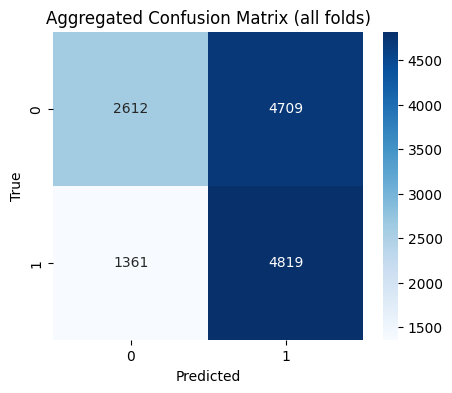

In [15]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Build pipeline: preprocessor must be the ColumnTransformer
clf = Pipeline([
    ("preproc", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=0))
])

# y[['predict']] 
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y
groups = df.loc[X.index, 'GRECO']  # ensure alignment

res_lr = evaluate_with_group_kfold(clf, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.8031, prec:0.3395, rec:0.4743, f1:0.3957, roc_auc:0.7646869828148631
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.34      0.47      0.40       506

    accuracy                           0.80      3723
   macro avg       0.63      0.66      0.64      3723
weighted avg       0.83      0.80      0.82      3723

Fold 1 — acc:0.7058, prec:0.6583, rec:0.9110, f1:0.7643, roc_auc:0.7649837143765053
              precision    recall  f1-score   support

           0       0.83      0.48      0.61      1616
           1       0.66      0.91      0.76      1776

    accuracy                           0.71      3392
   macro avg       0.74      0.70      0.69      3392
weighted avg       0.74      0.71      0.69      3392

Fold 2 — acc:0.6858, prec:0.6605, rec:0.7776, f1:0.7143, roc_auc:0.7470189901886368
              precision    recall  f1-score   support

           0       0.72      0.59      

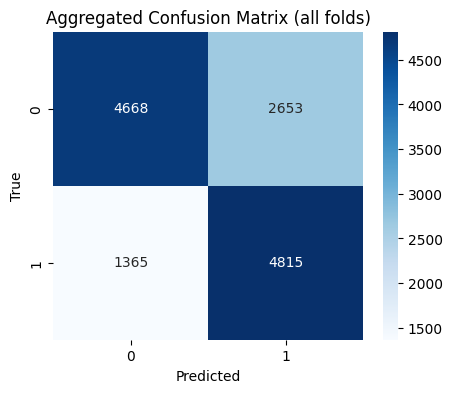

In [15]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ("preproc", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1))
])

res_rf = evaluate_with_group_kfold(clf, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.6873, prec:0.2303, rec:0.5553, f1:0.3256, roc_auc:0.6772853823745149
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      3217
           1       0.23      0.56      0.33       506

    accuracy                           0.69      3723
   macro avg       0.57      0.63      0.56      3723
weighted avg       0.82      0.69      0.73      3723

Fold 1 — acc:0.7022, prec:0.6600, rec:0.8896, f1:0.7578, roc_auc:0.7487789266680046
              precision    recall  f1-score   support

           0       0.80      0.50      0.61      1616
           1       0.66      0.89      0.76      1776

    accuracy                           0.70      3392
   macro avg       0.73      0.69      0.69      3392
weighted avg       0.73      0.70      0.69      3392

Fold 2 — acc:0.6826, prec:0.6572, rec:0.7764, f1:0.7119, roc_auc:0.7495856877793708
              precision    recall  f1-score   support

           0       0.72      0.59      

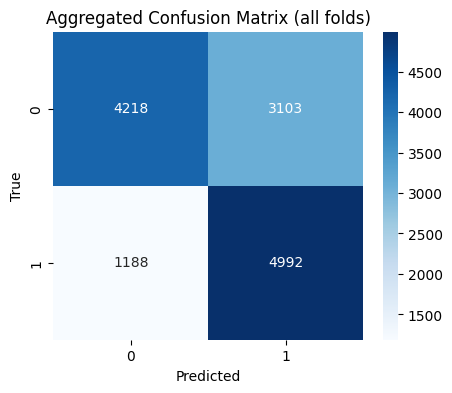

In [16]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

clf_gb = Pipeline([
    ("preproc", preprocessor),
    ("clf", HistGradientBoostingClassifier(max_iter=500, random_state=0))
])

res_gb = evaluate_with_group_kfold(clf_gb, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.6992, prec:0.2512, rec:0.6126, f1:0.3563, roc_auc:0.696836285985642
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      3217
           1       0.25      0.61      0.36       506

    accuracy                           0.70      3723
   macro avg       0.59      0.66      0.58      3723
weighted avg       0.83      0.70      0.74      3723

Fold 1 — acc:0.6960, prec:0.6519, rec:0.9003, f1:0.7562, roc_auc:0.740979841227366
              precision    recall  f1-score   support

           0       0.81      0.47      0.60      1616
           1       0.65      0.90      0.76      1776

    accuracy                           0.70      3392
   macro avg       0.73      0.69      0.68      3392
weighted avg       0.73      0.70      0.68      3392

Fold 2 — acc:0.6494, prec:0.6474, rec:0.6714, f1:0.6592, roc_auc:0.7028348233111242
              precision    recall  f1-score   support

           0       0.65      0.63      0.

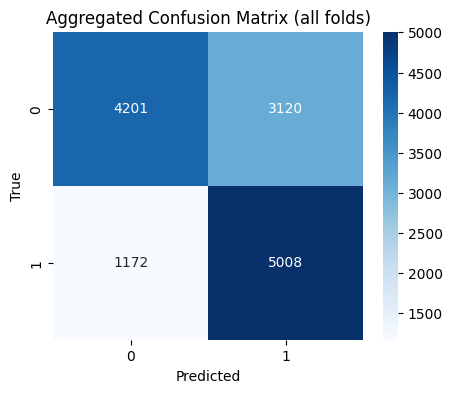

In [18]:
# SVC
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

clf_svc = Pipeline([
    ("preproc", preprocessor),
    ("clf", SVC(probability=True, kernel='rbf', C=1.0, random_state=0))
])

res_svc = evaluate_with_group_kfold(clf_svc, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.6355, prec:0.1923, rec:0.5257, f1:0.2816, roc_auc:0.6265639187075578
              precision    recall  f1-score   support

           0       0.90      0.65      0.76      3217
           1       0.19      0.53      0.28       506

    accuracy                           0.64      3723
   macro avg       0.54      0.59      0.52      3723
weighted avg       0.80      0.64      0.69      3723

Fold 1 — acc:0.6819, prec:0.6533, rec:0.8361, f1:0.7335, roc_auc:0.7173930389238248
              precision    recall  f1-score   support

           0       0.74      0.51      0.61      1616
           1       0.65      0.84      0.73      1776

    accuracy                           0.68      3392
   macro avg       0.70      0.67      0.67      3392
weighted avg       0.69      0.68      0.67      3392

Fold 2 — acc:0.6197, prec:0.6084, rec:0.6931, f1:0.6480, roc_auc:0.647573514941947
              precision    recall  f1-score   support

           0       0.64      0.54      0

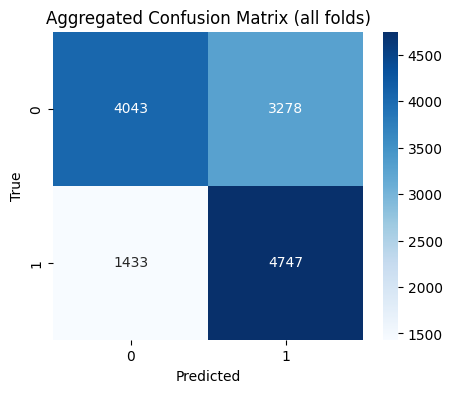

In [19]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

clf_knn = Pipeline([
    ("preproc", preprocessor),
    ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])

res_knn = evaluate_with_group_kfold(clf_knn, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.4993, prec:0.1471, rec:0.5593, f1:0.2329, roc_auc:0.4911380499593931
              precision    recall  f1-score   support

           0       0.88      0.49      0.63      3217
           1       0.15      0.56      0.23       506

    accuracy                           0.50      3723
   macro avg       0.51      0.52      0.43      3723
weighted avg       0.78      0.50      0.57      3723

Fold 1 — acc:0.6436, prec:0.5992, rec:0.9640, f1:0.7390, roc_auc:0.7287163207452503
              precision    recall  f1-score   support

           0       0.88      0.29      0.44      1616
           1       0.60      0.96      0.74      1776

    accuracy                           0.64      3392
   macro avg       0.74      0.63      0.59      3392
weighted avg       0.73      0.64      0.60      3392

Fold 2 — acc:0.6100, prec:0.5820, rec:0.8081, f1:0.6767, roc_auc:0.6760775983244778
              precision    recall  f1-score   support

           0       0.68      0.41      

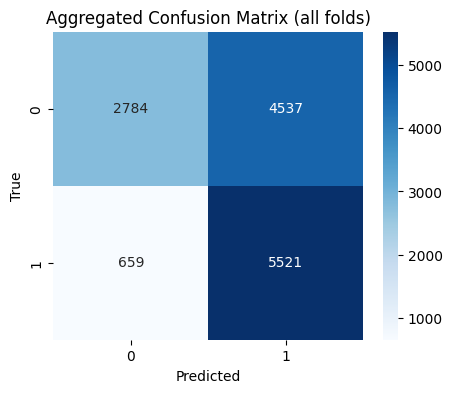

In [20]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

clf_nb = Pipeline([
    ("preproc", preprocessor),
    ("clf", GaussianNB())
])

res_nb = evaluate_with_group_kfold(clf_nb, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.5966, prec:0.1463, rec:0.4071, f1:0.2153, roc_auc:0.5152423329127253
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      3217
           1       0.15      0.41      0.22       506

    accuracy                           0.60      3723
   macro avg       0.51      0.52      0.47      3723
weighted avg       0.77      0.60      0.66      3723

Fold 1 — acc:0.7043, prec:0.6595, rec:0.8998, f1:0.7611, roc_auc:0.7239116436981536
              precision    recall  f1-score   support

           0       0.82      0.49      0.61      1616
           1       0.66      0.90      0.76      1776

    accuracy                           0.70      3392
   macro avg       0.74      0.69      0.69      3392
weighted avg       0.73      0.70      0.69      3392

Fold 2 — acc:0.6150, prec:0.6230, rec:0.6021, f1:0.6124, roc_auc:0.6545753563295943
              precision    recall  f1-score   support

           0       0.61      0.63      

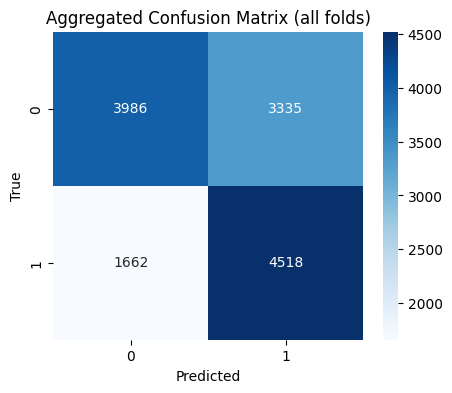

In [21]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline

clf_ab = Pipeline([
    ("preproc", preprocessor),
    ("clf", AdaBoostClassifier(n_estimators=200, random_state=0))
])

res_ab = evaluate_with_group_kfold(clf_ab, X, y_vec, groups, n_splits=4)


## ploting

In [23]:
import pandas as pd
import matplotlib.pyplot as plt


results = {
    'Model': ['Logistic Regression', 'Random Forest', 'GBoost', 'SVC', 'KNN', 'GaussianNB', 'AdaBoost'],
    'Accuracy': [0.561769, 0.699100, 0.682296, 0.681633, 0.651949,0.621233,  0.629945 ]
}

df_results = pd.DataFrame(results)


# ## ,
#     'Precision': [0.5964, 0.612, 0.631, 0.59, 0.57],
#     'Recall': [0.7226, 0.74, 0.756, 0.70, 0.68],
#     'F1': [0.6513, 0.667, 0.681, 0.63, 0.60],
#     'ROC_AUC': [0.7109, 0.726, 0.742, 0.702, 0.695]

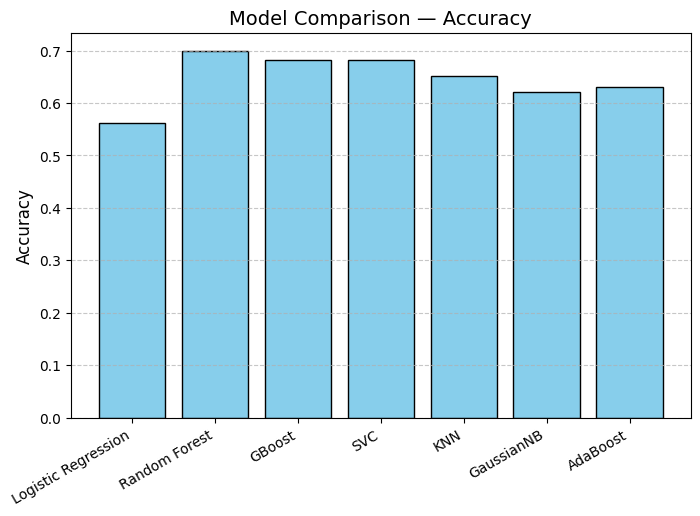

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(df_results['Model'], df_results['Accuracy'], color='skyblue', edgecolor='black')
plt.title('Model Comparison — Accuracy', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Feature Selection for better accuracy

Fold 0: perm importances shape = (39,), raw features = 39
Fold 1: perm importances shape = (39,), raw features = 39
Fold 2: perm importances shape = (39,), raw features = 39
Fold 3: perm importances shape = (39,), raw features = 39
Fold 4: perm importances shape = (39,), raw features = 39
Fold 5: perm importances shape = (39,), raw features = 39


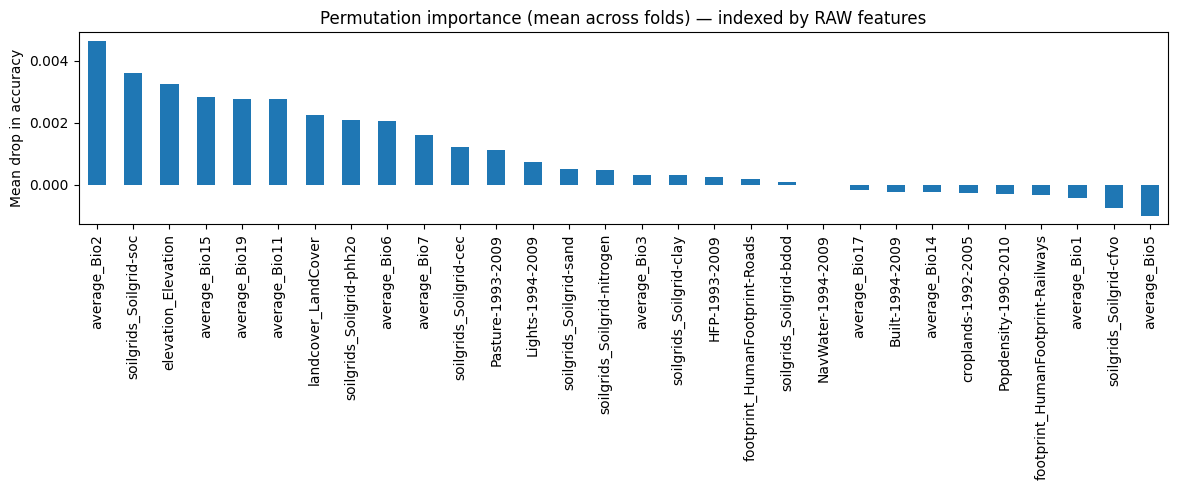

average_Bio2                         0.004635
soilgrids_Soilgrid-soc               0.003594
elevation_Elevation                  0.003247
average_Bio15                        0.002841
average_Bio19                        0.002768
average_Bio11                        0.002752
landcover_LandCover                  0.002240
soilgrids_Soilgrid-phh2o             0.002095
average_Bio6                         0.002066
average_Bio7                         0.001591
soilgrids_Soilgrid-cec               0.001227
Pasture-1993-2009                    0.001126
Lights-1994-2009                     0.000733
soilgrids_Soilgrid-sand              0.000502
soilgrids_Soilgrid-nitrogen          0.000469
average_Bio3                         0.000314
soilgrids_Soilgrid-clay              0.000310
HFP-1993-2009                        0.000262
footprint_HumanFootprint-Roads       0.000188
soilgrids_Soilgrid-bdod              0.000069
NavWater-1994-2009                   0.000000
average_Bio17                     

In [17]:
# Permutation importance per fold (GroupKFold) and average
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

n_splits = 6
gkf = GroupKFold(n_splits=n_splits)
groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

raw_feat_names = X.columns.to_list()   # RAW feature names
perm_vals = []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_vec.iloc[train_idx], y_vec.iloc[test_idx]

    pipe = Pipeline([
        ("preproc", preprocessor),   # the ColumnTransformer
        ("clf", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1))
    ])
    pipe.fit(X_train, y_train)

    # compute permutation importance ON THE RAW X_test (pipeline handles preprocessing inside)
    r = permutation_importance(pipe, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1, scoring='accuracy')
    print(f"Fold {fold_i}: perm importances shape = {r.importances_mean.shape}, raw features = {len(raw_feat_names)}")
    perm_vals.append(r.importances_mean)

# stack and average across folds
perm_arr = np.vstack(perm_vals)                # shape (n_splits, n_raw_features)
perm_mean = perm_arr.mean(axis=0)              # length == n_raw_features

# Create a Series indexed by RAW feature names
perm_series = pd.Series(perm_mean, index=raw_feat_names).sort_values(ascending=False)

# Plot top 25 raw features
plt.figure(figsize=(12,5))
perm_series.head(30).plot(kind='bar')
plt.title("Permutation importance (mean across folds) — indexed by RAW features")
plt.ylabel("Mean drop in accuracy")
plt.tight_layout()
plt.show()

# Print the top features
print(perm_series.head(40))




In [23]:
# Dropping low/negative features and evaluate
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# threshold (0 means dropping negative and zero)
threshold = 0.0
keep_features = perm_series[perm_series > threshold].index.tolist()
drop_features = [f for f in X.columns if f not in keep_features]

print(f"Keeping {len(keep_features)} features, dropping {len(drop_features)} features")

X_reduced = X[keep_features].copy()
groups_reduced = df.loc[X_reduced.index, 'GRECO']

# build preprocessor for reduced set
cat_cols = [c for c in X_reduced.columns if c.startswith('landcover') or X_reduced[c].dtype == 'object']
num_cols = [c for c in X_reduced.columns if c not in cat_cols]

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preproc_reduced = ColumnTransformer([("num", numeric_transformer, num_cols),
                                     ("cat", categorical_transformer, cat_cols)], remainder='drop')

pipe_reduced = Pipeline([("preproc", preproc_reduced), ("clf", RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1))])

# Evaluate original (on full X) and reduced (X_reduced)
print("Evaluating original RF on full X:")
res_full = evaluate_with_group_kfold(Pipeline([("preproc", preprocessor), ("clf", RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1))]), X, y_vec, groups=df.loc[X.index,'GRECO'], n_splits=4, plot_cm=False)

print("\nEvaluating RF on reduced feature set:")
res_reduced = evaluate_with_group_kfold(pipe_reduced, X_reduced, y_vec, groups=groups_reduced, n_splits=8, plot_cm=False)

print("\nMean accuracy full: {:.4f}".format(res_full['summary_df']['accuracy'].mean()))
print("Mean accuracy reduced: {:.4f}".format(res_reduced['summary_df']['accuracy'].mean()))


Keeping 20 features, dropping 19 features
Evaluating original RF on full X:
Fold 0 — acc:0.7994, prec:0.3329, rec:0.4743, f1:0.3912, roc_auc:0.7620478411993596
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.33      0.47      0.39       506

    accuracy                           0.80      3723
   macro avg       0.62      0.66      0.64      3723
weighted avg       0.83      0.80      0.81      3723

Fold 1 — acc:0.7070, prec:0.6589, rec:0.9127, f1:0.7653, roc_auc:0.7644617660668094
              precision    recall  f1-score   support

           0       0.83      0.48      0.61      1616
           1       0.66      0.91      0.77      1776

    accuracy                           0.71      3392
   macro avg       0.75      0.70      0.69      3392
weighted avg       0.74      0.71      0.69      3392

Fold 2 — acc:0.6894, prec:0.6643, rec:0.7782, f1:0.7168, roc_auc:0.7486370568721712
              prec

## Trying to drop Human footprint

In [44]:
X.shape

(13501, 39)

In [18]:
X.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc',
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'],
      dtype='object')

X_mod shape: (13501, 30)
Fold 0 — acc:0.7983, prec:0.3277, rec:0.4605, f1:0.3829, roc_auc:0.7550282528219034
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.33      0.46      0.38       506

    accuracy                           0.80      3723
   macro avg       0.62      0.66      0.63      3723
weighted avg       0.83      0.80      0.81      3723

Fold 1 — acc:0.6549, prec:0.6549, rec:0.9980, f1:0.7908, roc_auc:0.6292378079643938
              precision    recall  f1-score   support

           0       0.67      0.01      0.02       786
           1       0.65      1.00      0.79      1483

    accuracy                           0.65      2269
   macro avg       0.66      0.50      0.40      2269
weighted avg       0.66      0.65      0.52      2269

Fold 2 — acc:0.7158, prec:0.6826, rec:0.7336, f1:0.7072, roc_auc:0.7922504850665752
              precision    recall  f1-score   support

           0  

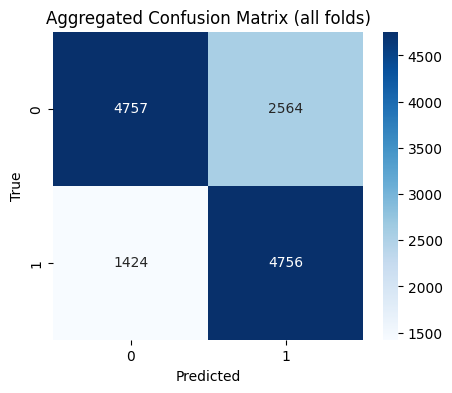

In [22]:
hf_cols = [
'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'
]

X_mod = X.drop(columns=[c for c in hf_cols if c in X.columns]).copy()
groups_mod = df.loc[X_mod.index, 'GRECO']
print("X_mod shape:", X_mod.shape)

# Rebuild a local preprocessor from X_mod columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

cat_cols = [c for c in X_mod.columns if c.startswith('landcover') or X_mod[c].dtype == 'object']
num_cols = [c for c in X_mod.columns if c not in cat_cols]

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preproc_mod = ColumnTransformer([("num", numeric_transformer, num_cols),
                                 ("cat", categorical_transformer, cat_cols)], remainder='drop')

pipe_mod = Pipeline([("preproc", preproc_mod), ("clf", RandomForestClassifier(n_estimators=1500, random_state=0, n_jobs=-1))])

res_rf_mod = evaluate_with_group_kfold(pipe_mod, X_mod, y_vec, groups=groups_mod, n_splits=9)


## Dummy Classifier

Fold 0 — acc:0.7983, prec:0.3277, rec:0.4605, f1:0.3829, roc_auc:0.7550282528219034
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.33      0.46      0.38       506

    accuracy                           0.80      3723
   macro avg       0.62      0.66      0.63      3723
weighted avg       0.83      0.80      0.81      3723

Fold 1 — acc:0.6549, prec:0.6549, rec:0.9980, f1:0.7908, roc_auc:0.6292378079643938
              precision    recall  f1-score   support

           0       0.67      0.01      0.02       786
           1       0.65      1.00      0.79      1483

    accuracy                           0.65      2269
   macro avg       0.66      0.50      0.40      2269
weighted avg       0.66      0.65      0.52      2269

Fold 2 — acc:0.7158, prec:0.6826, rec:0.7336, f1:0.7072, roc_auc:0.7922504850665752
              precision    recall  f1-score   support

           0       0.75      0.70      

<Figure size 800x500 with 0 Axes>

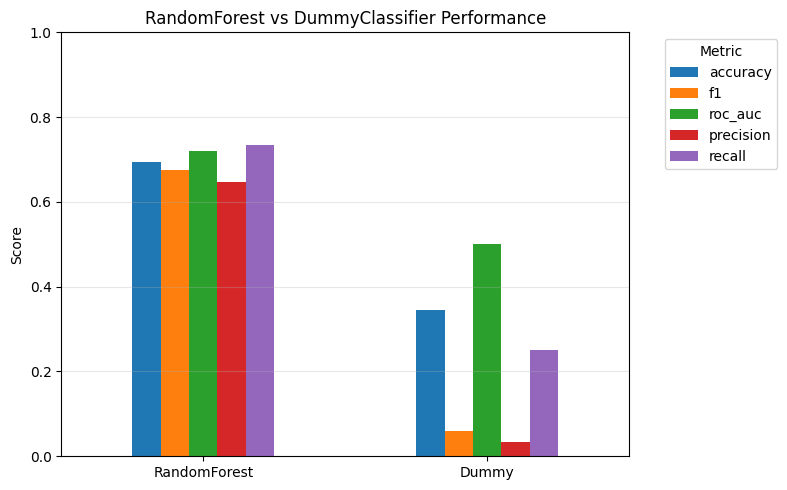

In [25]:
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Evaluate RandomForest
rf_res = evaluate_with_group_kfold(pipe_mod, X, y, groups=df.loc[X.index, 'GRECO'], n_splits=7, plot_cm=False)
rf_summary = rf_res["summary_df"].mean()

# Evaluate DummyClassifier
dummy_pipe = Pipeline([
    ("preproc", preprocessor),
    ("clf", DummyClassifier(strategy="most_frequent"))  # predicts majority class
])

dummy_res = evaluate_with_group_kfold(dummy_pipe, X, y, groups=df.loc[X.index, 'GRECO'], n_splits=4, plot_cm=False)
dummy_summary = dummy_res["summary_df"].mean()

# Combine results into DataFrame
compare_df = pd.DataFrame({
    "RandomForest": rf_summary,
    "Dummy": dummy_summary
})

print(compare_df)

# Visualization
metrics = ["accuracy", "f1", "roc_auc", "precision", "recall"]
plt.figure(figsize=(8, 5))
compare_df.loc[metrics].T.plot(kind="bar", figsize=(8,5), rot=0)
plt.title("RandomForest vs DummyClassifier Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 